In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as si
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Pendulo doble simplificado

Las variables son $\theta_1$, $\theta_2$, $v_{\theta_1}$ y $v_{\theta_2}$. Las ecuaciones de movimiento son

$$
\dot \theta_1 = v_{\theta_1} \\
\dot \theta_2 = v_{\theta_2} \\
\dot v_{\theta_1} = \frac{-3g\sin \theta_1 -g\sin (\theta_1 -2\theta _2) - 2(v^2_{\theta_2} + v^2_{\theta_1}\cos(\theta_1 - \theta_2) ) \sin(\theta _1 - \theta _2)}{3 - \cos(2\theta_1 - 2\theta_2)} \\
\dot v_{\theta_1} = \frac{ 2\sin(\theta_1 - \theta_2)(2 v ^2 _{\theta_1} + 2g\cos\theta_1 + v^2 _{\theta _2} \cos (\theta _1 - \theta _2) ) }{3 - \cos(2\theta_1 - 2\theta_2)} 
$$

In [2]:
def pendulo_doble(t,th_vth):
    g = 9.81
    # th_vth = [th1 , th2 , vth1 , vth2]
    dth1 = th_vth[2]
    dth2 = th_vth[3]
    d_th1th2 = th_vth[0]-th_vth[1]
    den = 3 -np.cos(2*d_th1th2)
    dvth1 = -3*g*np.sin(th_vth[0]) - g*np.sin(th_vth[0]-2*th_vth[1]) 
    -2*np.sin(d_th1th2)*(th_vth[3]**2 + th_vth[2]**2*np.cos(d_th1th2))
    dvth1 = dvth1/den
    dvth2 = 2*np.sin(d_th1th2)*(2*th_vth[2]**2 + 
                                2*g*np.cos(th_vth[0]) + th_vth[3]**2*np.cos(d_th1th2))
    dvth2 = dvth2/den
    return np.array([dth1,dth2,dvth1,dvth2])

def th2xy(th_vth):
    x1 = np.sin(th_vth[0])
    y1 = -np.cos(th_vth[0])
    x2 = x1 + np.sin(th_vth[1])
    y2 = y1 -np.cos(th_vth[1])
    return x1,y1,x2,y2

In [3]:
ci = [0.5,0.5,0,0]
titf = (0,100)
sol_pendulo = si.solve_ivp(pendulo_doble,titf,ci,rtol=1e-8,atol=1e-10,
                        dense_output=True)
print(sol_pendulo.success)

True


In [4]:
t = np.linspace(titf[0],titf[1],1000)
th_vth = sol_pendulo.sol(t)
x1,y1,x2,y2 = th2xy(th_vth)

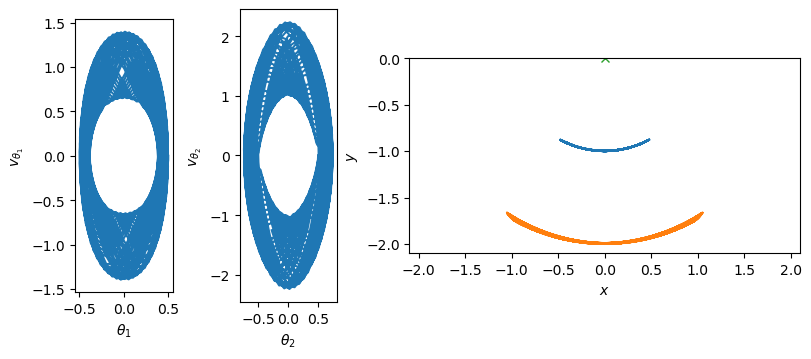

In [5]:
fig , ejes = plt.subplots(1,3,gridspec_kw= {'width_ratios':[1,1,4]},
                          layout="constrained",
                         figsize=(8,6))
ejes[0].plot(th_vth[0,:],th_vth[2,:])
ejes[1].plot(th_vth[1,:],th_vth[3,:])
ejes[2].plot(x1,y1)
ejes[2].plot(x2,y2)
ejes[2].plot([0],[0],'x')
#
ejes[0].set_xlabel(r'$\theta _1$'), ejes[0].set_ylabel(r'$v _{\theta _1}$')
ejes[1].set_xlabel(r'$\theta _2$'), ejes[1].set_ylabel(r'$v _{\theta _2}$')
ejes[2].set_xlabel(r'$x$'), ejes[2].set_ylabel(r'$y$')
ejes[2].set_xlim([-2.1,2.1]) , ejes[2].set_ylim([-2.1,0])
ejes[0].set_aspect('equal')
ejes[1].set_aspect('equal')
ejes[2].set_aspect('equal')
plt.show()

In [6]:
figura , ejes = plt.subplots()

masa1, = ejes.plot(x1[0],y1[0],'o')
masa2, = ejes.plot(x2[0],y2[0],'o')
cuerda1, = ejes.plot([0,x1[0]],[0,y1[0]])
cuerda2, = ejes.plot( [x1[0],x2[0]] , [y1[0],y2[0]])
ejes.set_xlim([-2.1,2.1]) , ejes.set_ylim([-2.1,0])

def cuadro(n):
    masa1.set_data([x1[n]],[y1[n]])
    masa2.set_data([x2[n]],[y2[n]])
    cuerda1.set_data([0,x1[n]],[0,y1[n]])
    cuerda2.set_data([x1[n],x2[n]],[y1[n],y2[n]])
    return masa1,masa2,

animacion = FuncAnimation(figura,cuadro,frames=len(t), interval = 41,blit=True)

plt.close()
HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
#HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video

In [7]:
mfx = max(abs(th_vth[0,:]).max(),abs(th_vth[1,:]).max())
mfy = max(abs(th_vth[2,:]).max(),abs(th_vth[3,:]).max())
mfx,mfy
plt.rcParams['animation.embed_limit'] = 50 

In [8]:
figura , ejes = plt.subplots(1,3,gridspec_kw= {'width_ratios':[1,1,4]},
                          layout="constrained",
                         figsize=(8,6))
#configuracion de la figura
ejes[0].set_xlabel(r'$\theta _1$'), ejes[0].set_ylabel(r'$v _{\theta _1}$')
ejes[1].set_xlabel(r'$\theta _2$'), ejes[1].set_ylabel(r'$v _{\theta _2}$')
ejes[2].set_xlabel(r'$x$'), ejes[2].set_ylabel(r'$y$')
ejes[0].set_xlim([-mfx,mfx]) , ejes[0].set_ylim([-mfy,mfy])
ejes[1].set_xlim([-mfx,mfx]) , ejes[1].set_ylim([-mfy,mfy])
ejes[2].set_xlim([-2.1,2.1]) , ejes[2].set_ylim([-2.1,0])
ejes[0].set_aspect('equal')
ejes[1].set_aspect('equal')
ejes[2].set_aspect('equal')
# Primer cuadro y variables iterables
fase_m1, = ejes[0].plot(th_vth[0,0],th_vth[2,0])
fase_m2, = ejes[1].plot(th_vth[1,0],th_vth[3,0])
masa1, = ejes[2].plot(x1[0],y1[0],'o')
masa2, = ejes[2].plot(x2[0],y2[0],'o')
cuerda1, = ejes[2].plot([0,x1[0]],[0,y1[0]])
cuerda2, = ejes[2].plot( [x1[0],x2[0]] , [y1[0],y2[0]])

def cuadro(n):
    fase_m1.set_data([th_vth[0,:n]],[th_vth[2,:n]])
    fase_m2.set_data([th_vth[1,:n]],[th_vth[3,:n]]) 
    masa1.set_data([x1[n]],[y1[n]])
    masa2.set_data([x2[n]],[y2[n]])
    cuerda1.set_data([0,x1[n]],[0,y1[n]])
    cuerda2.set_data([x1[n],x2[n]],[y1[n],y2[n]])
    return fase_m1,fase_m2,masa1,masa2,cuerda1,cuerda2

animacion = FuncAnimation(figura,cuadro,frames=len(t), interval = 41,blit=True)

plt.close()
HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
#HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video